In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
!pip install scikeras

In [7]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

# Evaluation Libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

# Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation, Dropout
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier

In [8]:
%cd /content/drive/MyDrive/Colab Notebooks

/content/drive/MyDrive/Colab Notebooks


In [11]:
## 2. Loading the Fashion MNIST Dataset
### Reading training and testing datasets

fashion_train = pd.read_csv("fashion-mnist_train.csv")
fashion_test = pd.read_csv("fashion-mnist_test.csv")

In [15]:
## Checking Dataset Shape
### Displaying rows and columns of the dataset

fashion_train.shape

(60000, 785)

In [16]:
## Splitting Features and Labels
### Separating input features and target labels

X_train_fashion = fashion_train.drop('label',axis=1)
y_train_fashion = fashion_train['label']

X_test_fashion = fashion_test.drop('label',axis=1)
y_test_fashion = fashion_test['label']

In [20]:
fashion_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,1,0,0,0,0,0,0,0,0,0,...,73,0,0,0,0,0,0,0,0,0
59997,8,0,0,0,0,0,0,0,0,0,...,160,162,163,135,94,0,0,0,0,0
59998,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
fashion_test

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,0,0,0,0,0,0,0,0,0,...,32,23,14,20,0,0,1,0,0,0
9996,6,0,0,0,0,0,0,0,0,0,...,0,0,0,2,52,23,28,0,0,0
9997,8,0,0,0,0,0,0,0,0,0,...,175,172,172,182,199,222,42,0,1,0
9998,8,0,1,3,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0


In [22]:
# Display dataset information
fashion_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 359.3 MB


In [23]:
# Display statistical summary
fashion_train.describe()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000
mean,4.500000,0.000900,0.006150,0.035333,0.101933,0.247967,0.411467,0.805767,2.198283,5.682000,...,34.625400,23.300683,16.588267,17.869433,22.814817,17.911483,8.520633,2.753300,0.855517,0.07025
std,2.872305,0.094689,0.271011,1.222324,2.452871,4.306912,5.836188,8.215169,14.093378,23.819481,...,57.545242,48.854427,41.979611,43.966032,51.830477,45.149388,29.614859,17.397652,9.356960,2.12587
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,4.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,58.000000,9.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,9.000000,16.000000,36.000000,226.000000,164.000000,227.000000,230.000000,224.000000,255.000000,254.000000,...,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,170.00000


In [24]:
# Display column names
fashion_train.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

In [25]:
# Display shape (rows, columns)
fashion_train.shape

(60000, 785)

In [26]:
# Display all column names as a list
print(fashion_train.columns.tolist())

['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6', 'pixel7', 'pixel8', 'pixel9', 'pixel10', 'pixel11', 'pixel12', 'pixel13', 'pixel14', 'pixel15', 'pixel16', 'pixel17', 'pixel18', 'pixel19', 'pixel20', 'pixel21', 'pixel22', 'pixel23', 'pixel24', 'pixel25', 'pixel26', 'pixel27', 'pixel28', 'pixel29', 'pixel30', 'pixel31', 'pixel32', 'pixel33', 'pixel34', 'pixel35', 'pixel36', 'pixel37', 'pixel38', 'pixel39', 'pixel40', 'pixel41', 'pixel42', 'pixel43', 'pixel44', 'pixel45', 'pixel46', 'pixel47', 'pixel48', 'pixel49', 'pixel50', 'pixel51', 'pixel52', 'pixel53', 'pixel54', 'pixel55', 'pixel56', 'pixel57', 'pixel58', 'pixel59', 'pixel60', 'pixel61', 'pixel62', 'pixel63', 'pixel64', 'pixel65', 'pixel66', 'pixel67', 'pixel68', 'pixel69', 'pixel70', 'pixel71', 'pixel72', 'pixel73', 'pixel74', 'pixel75', 'pixel76', 'pixel77', 'pixel78', 'pixel79', 'pixel80', 'pixel81', 'pixel82', 'pixel83', 'pixel84', 'pixel85', 'pixel86', 'pixel87', 'pixel88', 'pixel89', 'pixel90', 'pixel91'

In [27]:
# Display complete table (not recommended for 60,000 rows)
pd.set_option('display.max_columns', None)
fashion_train

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel122,pixel123,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel139,pixel140,pixel141,pixel142,pixel143,pixel144,pixel145,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel161,pixel162,pixel163,pixel164,pixel165,pixel166,pixel167,pixel168,pixel169,pixel170,pixel171,pixel172,pixel173,pixel174,pixel175,pixel176,pixel177,pixel178,pixel179,pixel180,pixel181,pixel182,pixel183,pixel184,pixel185,pixel186,pixel187,pixel188,pixel189,pixel190,pixel191,pixel192,pixel193,pixel194,pixel195,pixel196,pixel197,pixel198,pixel199,pixel200,pixel201,pixel202,pixel203,pixel204,pixel205,pixel206,pixel207,pixel208,pixel209,pixel210,pixel211,pixel212,pixel213,pixel214,pixel215,pixel216,pixel217,pixel218,pixel219,pixel220,pixel221,pixel222,pixel223,pixel224,pixel225,pixel226,pixel227,pixel228,pixel229,pixel230,pixel231,pixel232,pixel233,pixel234,pixel235,pixel236,pixel237,pixel238,pixel239,pixel240,pixel241,pixel242,pixel243,pixel244,pixel245,pixel246,pixel247,pixel248,pixel249,pixel250,pixel251,pixel252,pixel253,pixel254,pixel255,pixel256,pixel257,pixel258,pixel259,pixel260,pixel261,pixel262,pixel263,pixel264,pixel265,pixel266,pixel267,pixel268,pixel269,pixel270,pixel271,pixel272,pixel273,pixel274,pixel275,pixel276,pixel277,pixel278,pixel279,pixel280,pixel281,pixel282,pixel283,pixel284,pixel285,pixel286,pixel287,pixel288,pixel289,pixel290,pixel291,pixel292,pixel293,pixel294,pixel295,pixel296,pixel297,pixel298,pixel299,pixel300,pixel301,pixel302,pixel303,pixel304,pixel305,pixel306,pixel307,pixel308,pixel309,pixel310,pixel311,pixel312,pixel313,pixel314,pixel315,pixel316,pixel317,pixel318,pixel319,pixel320,pixel321,pixel322,pixel323,pixel324,pixel325,pixel326,pixel327,pixel328,pixel329,pixel330,pixel331,pixel332,pixel333,pixel334,pixel335,pixel336,pixel337,pixel338,pixel339,pixel340,pixel341,pixel342,pixel343,pixel344,pixel345,pixel346,pixel347,pixel348,pixel349,pixel350,pixel351,pixel352,pixel353,pixel354,pixel355,pixel356,pixel357,pixel358,pixel359,pixel360,pixel361,pixel362,pixel363,pixel364,pixel365,pixel366,pixel367,pixel368,pixel369,pixel370,pixel371,pixel372,pixel373,pixel374,pixel375,pixel376,pixel377,pixel378,pixel379,pixel380,pixel381,pixel382,pixel383,pixel384,pixel385,pixel386,pixel387,pixel388,pixel389,pixel390,pixel391,pixel392,pixel393,pixel394,pixel395,pixel396,pixel397,pixel398,pixel399,pixel400,pixel401,pixel402,pixel403,pixel404,pixel405,pixel406,pixel407,pixel408,pixel409,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417,pixel418,pixel419,pixel420,pixel421,pixel422,pixel423,pixel424,pixel425,pixel426,pixel427,pixel428,pixel429,pixel430,pixel431,pixel432,pixel433,pixel434,pixel435,pixel436,pixel437,pixel438,pixel439,pixel440,pixel441,pixel442,pixel443,pixel444,pixel445,pixel446,pixel447,pixel448,pixel449,pixel450,pixel451,pixel452,pixel453,pixel454,pixel455,pixel4

In [28]:
# Read and display raw CSV file
pd.read_csv("fashion-mnist_train.csv").head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,pixel11,pixel12,pixel13,pixel14,pixel15,pixel16,pixel17,pixel18,pixel19,pixel20,pixel21,pixel22,pixel23,pixel24,pixel25,pixel26,pixel27,pixel28,pixel29,pixel30,pixel31,pixel32,pixel33,pixel34,pixel35,pixel36,pixel37,pixel38,pixel39,pixel40,pixel41,pixel42,pixel43,pixel44,pixel45,pixel46,pixel47,pixel48,pixel49,pixel50,pixel51,pixel52,pixel53,pixel54,pixel55,pixel56,pixel57,pixel58,pixel59,pixel60,pixel61,pixel62,pixel63,pixel64,pixel65,pixel66,pixel67,pixel68,pixel69,pixel70,pixel71,pixel72,pixel73,pixel74,pixel75,pixel76,pixel77,pixel78,pixel79,pixel80,pixel81,pixel82,pixel83,pixel84,pixel85,pixel86,pixel87,pixel88,pixel89,pixel90,pixel91,pixel92,pixel93,pixel94,pixel95,pixel96,pixel97,pixel98,pixel99,pixel100,pixel101,pixel102,pixel103,pixel104,pixel105,pixel106,pixel107,pixel108,pixel109,pixel110,pixel111,pixel112,pixel113,pixel114,pixel115,pixel116,pixel117,pixel118,pixel119,pixel120,pixel121,pixel122,pixel123,pixel124,pixel125,pixel126,pixel127,pixel128,pixel129,pixel130,pixel131,pixel132,pixel133,pixel134,pixel135,pixel136,pixel137,pixel138,pixel139,pixel140,pixel141,pixel142,pixel143,pixel144,pixel145,pixel146,pixel147,pixel148,pixel149,pixel150,pixel151,pixel152,pixel153,pixel154,pixel155,pixel156,pixel157,pixel158,pixel159,pixel160,pixel161,pixel162,pixel163,pixel164,pixel165,pixel166,pixel167,pixel168,pixel169,pixel170,pixel171,pixel172,pixel173,pixel174,pixel175,pixel176,pixel177,pixel178,pixel179,pixel180,pixel181,pixel182,pixel183,pixel184,pixel185,pixel186,pixel187,pixel188,pixel189,pixel190,pixel191,pixel192,pixel193,pixel194,pixel195,pixel196,pixel197,pixel198,pixel199,pixel200,pixel201,pixel202,pixel203,pixel204,pixel205,pixel206,pixel207,pixel208,pixel209,pixel210,pixel211,pixel212,pixel213,pixel214,pixel215,pixel216,pixel217,pixel218,pixel219,pixel220,pixel221,pixel222,pixel223,pixel224,pixel225,pixel226,pixel227,pixel228,pixel229,pixel230,pixel231,pixel232,pixel233,pixel234,pixel235,pixel236,pixel237,pixel238,pixel239,pixel240,pixel241,pixel242,pixel243,pixel244,pixel245,pixel246,pixel247,pixel248,pixel249,pixel250,pixel251,pixel252,pixel253,pixel254,pixel255,pixel256,pixel257,pixel258,pixel259,pixel260,pixel261,pixel262,pixel263,pixel264,pixel265,pixel266,pixel267,pixel268,pixel269,pixel270,pixel271,pixel272,pixel273,pixel274,pixel275,pixel276,pixel277,pixel278,pixel279,pixel280,pixel281,pixel282,pixel283,pixel284,pixel285,pixel286,pixel287,pixel288,pixel289,pixel290,pixel291,pixel292,pixel293,pixel294,pixel295,pixel296,pixel297,pixel298,pixel299,pixel300,pixel301,pixel302,pixel303,pixel304,pixel305,pixel306,pixel307,pixel308,pixel309,pixel310,pixel311,pixel312,pixel313,pixel314,pixel315,pixel316,pixel317,pixel318,pixel319,pixel320,pixel321,pixel322,pixel323,pixel324,pixel325,pixel326,pixel327,pixel328,pixel329,pixel330,pixel331,pixel332,pixel333,pixel334,pixel335,pixel336,pixel337,pixel338,pixel339,pixel340,pixel341,pixel342,pixel343,pixel344,pixel345,pixel346,pixel347,pixel348,pixel349,pixel350,pixel351,pixel352,pixel353,pixel354,pixel355,pixel356,pixel357,pixel358,pixel359,pixel360,pixel361,pixel362,pixel363,pixel364,pixel365,pixel366,pixel367,pixel368,pixel369,pixel370,pixel371,pixel372,pixel373,pixel374,pixel375,pixel376,pixel377,pixel378,pixel379,pixel380,pixel381,pixel382,pixel383,pixel384,pixel385,pixel386,pixel387,pixel388,pixel389,pixel390,pixel391,pixel392,pixel393,pixel394,pixel395,pixel396,pixel397,pixel398,pixel399,pixel400,pixel401,pixel402,pixel403,pixel404,pixel405,pixel406,pixel407,pixel408,pixel409,pixel410,pixel411,pixel412,pixel413,pixel414,pixel415,pixel416,pixel417,pixel418,pixel419,pixel420,pixel421,pixel422,pixel423,pixel424,pixel425,pixel426,pixel427,pixel428,pixel429,pixel430,pixel431,pixel432,pixel433,pixel434,pixel435,pixel436,pixel437,pixel438,pixel439,pixel440,pixel441,pixel442,pixel443,pixel444,pixel445,pixel446,pixel447,pixel448,pixel449,pixel450,pixel451,pixel452,pixel453,pixel454,pixel455,pixel4

In [32]:
## Reshaping the Dataset
### Converting image data into 28×28 format for processing

# Reshaping the dataset
X_train_reshape = X_train_fashion.values.reshape(-1,28,28)
X_test_reshape = X_test_fashion.values.reshape(-1,28,28)

means:

-1 → automatically determine number of images
28 → image height
28 → image width

=====

array.reshape(rows, height, width)

In [33]:
## Defining Clothing Categories
### Creating labels for Fashion-MNIST classes

# Names of clothing accessories in order
col_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

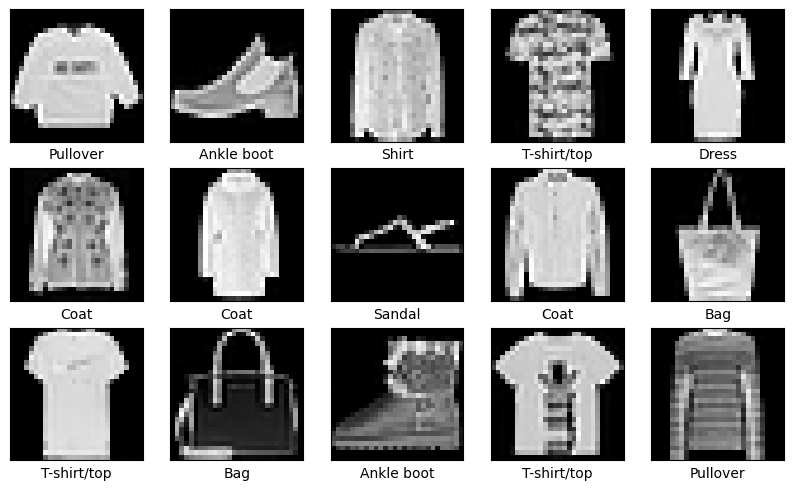

In [34]:
## Visualizing Sample Images
### Displaying Fashion-MNIST images with category labels

# Visualizing the images
plt.figure(figsize=(10,10))

for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_reshape[i], cmap='gray')
    plt.xlabel(col_names[y_train_fashion[i]])

plt.show()

| Step |                                          Code | Purpose                                                           |
| ---- | --------------------------------------------: | ----------------------------------------------------------------- |
| 1    |                 `plt.figure(figsize=(10,10))` | Create a figure/canvas for displaying images                      |
| 2    |                         `for i in range(15):` | Loop through the first 15 images                                  |
| 3    |                        `plt.subplot(5,5,i+1)` | Divide the figure into rows and columns and assign image position |
| 4    |                              `plt.xticks([])` | Remove x-axis values                                              |
| 5    |                              `plt.yticks([])` | Remove y-axis values                                              |
| 6    | `plt.imshow(X_train_reshape[i], cmap='gray')` | Display the selected image in grayscale                           |
| 7    |   `plt.xlabel(col_names[y_train_fashion[i]])` | Add clothing category label below the image                       |
| 8    |                                  `plt.show()` | Display all generated images on the screen                        |


=================

| Process Flow           |
| ---------------------- |
| Create Figure          |
| ↓                      |
| Loop through 15 Images |
| ↓                      |
| Create Subplot         |
| ↓                      |
| Remove Axes            |
| ↓                      |
| Display Image          |
| ↓                      |
| Add Clothing Name      |
| ↓                      |
| Show Images            |


In [35]:
## Converting Labels into Categorical Format
### Transforming target labels into one-hot encoded vectors

y_train_fashion = to_categorical(y_train_fashion, num_classes=10)
y_test_fashion = to_categorical(y_test_fashion, num_classes=10)

In [38]:
# Display first 5 one-hot encoded labels
y_train_fashion[:5]

array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]])

In [40]:
#compare original label vs encoded label

print("Original Label:", fashion_train['label'][0])
print("One-Hot Vector:", y_train_fashion[5])

Original Label: 2
One-Hot Vector: [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


| Label | One-Hot Encoded Vector  |
| ----- | ----------------------- |
| 0     | `[1,0,0,0,0,0,0,0,0,0]` |
| 1     | `[0,1,0,0,0,0,0,0,0,0]` |
| 5     | `[0,0,0,0,0,1,0,0,0,0]` |

==========

The 1 indicates the correct class position and all others become 0.

In [42]:
## Model Creation
#Building Artificial Neural Network (ANN)
### Creating the neural network architecture with hidden layers

# Creating base neural network
model = keras.Sequential([

    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),

    layers.BatchNormalization(),

    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),

    layers.BatchNormalization(),

    layers.Dense(24, activation='relu'),
    layers.Dropout(0.3),

    layers.BatchNormalization(),

    layers.Dense(10, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


| Layer              |       Configuration | Purpose                |
| ------------------ | ------------------: | ---------------------- |
| Input Layer        |          784 inputs | Receive image pixels   |
| Hidden Layer 1     |   Dense(128) + ReLU | Learn features         |
| Dropout            |                 0.3 | Reduce overfitting     |
| BatchNormalization |                   — | Normalize values       |
| Hidden Layer 2     |    Dense(24) + ReLU | Learn deeper features  |
| Dropout            |                 0.3 | Reduce overfitting     |
| BatchNormalization |                   — | Normalize values       |
| Hidden Layer 3     |    Dense(24) + ReLU | Extract patterns       |
| Dropout            |                 0.3 | Reduce overfitting     |
| BatchNormalization |                   — | Normalize values       |
| Output Layer       | Dense(10) + Softmax | Predict clothing class |


In [43]:
## Compiling the Model
### Configuring loss function, optimizer, and evaluation metrics

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [44]:
## Training the ANN Model
### Training the model using training and validation datasets

history = model.fit(
    X_train_fashion,
    y_train_fashion,
    batch_size=100,
    epochs=30,
    validation_data=(X_test_fashion, y_test_fashion)
)

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6221 - loss: 1.0969 - val_accuracy: 0.7724 - val_loss: 0.6148
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7473 - loss: 0.7393 - val_accuracy: 0.8400 - val_loss: 0.4915
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7728 - loss: 0.6717 - val_accuracy: 0.8457 - val_loss: 0.4390
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7826 - loss: 0.6492 - val_accuracy: 0.8530 - val_loss: 0.4648
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7941 - loss: 0.6192 - val_accuracy: 0.8534 - val_loss: 0.4639
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7999 - loss: 0.6017 - val_accuracy: 0.8550 - val_loss: 0.4507
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8059 - loss: 0.5863 - val_accuracy: 0.8571 - val_loss: 0.4189
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8099 - loss: 0.5721 - val_accuracy:

In [45]:
## Evaluating Model Performance
### Calculating test loss and test accuracy using the trained model

test_loss_fashion, test_acc_fashion = model.evaluate(
    X_test_fashion,
    y_test_fashion
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8751 - loss: 0.3747


In [46]:
## Displaying Model Accuracy
### Printing Fashion-MNIST test accuracy score

print("Fashion MNIST Test accuracy:", round(test_acc_fashion,4))

Fashion MNIST Test accuracy: 0.8751


Meaning:

0.8714 → decimal accuracy,

87.14% → percentage accuracy

To display as percentage:

In [47]:
print("Fashion MNIST Test accuracy:", round(test_acc_fashion*100,2), "%")

Fashion MNIST Test accuracy: 87.51 %


In [48]:
## Predicting Fashion Categories
### Generating predictions using the trained ANN model

# Predicting the Labels-Fashion
y_predict_fash = model.predict(X_test_fashion)

y_predict_fash = np.argmax(y_predict_fash, axis=1)
y_test_fash_eval = np.argmax(y_test_fashion, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


| Line                                                   |                                                              Explanation | Why Needed                                    |
| ------------------------------------------------------ | -----------------------------------------------------------------------: | --------------------------------------------- |
| `y_predict_fash = model.predict(X_test_fashion)`       | Sends test images to the trained model and gets prediction probabilities | Model predicts probabilities for each class   |
| `y_predict_fash = np.argmax(y_predict_fash, axis=1)`   |                           Selects the index with the highest probability | Converts probabilities into a class label     |
| `y_test_fash_eval = np.argmax(y_test_fashion, axis=1)` |                    Converts one-hot encoded labels back to class numbers | Required for comparison with predicted labels |


==========

| Process                    |
| -------------------------- |
| Test Images                |
| ↓                          |
| `model.predict()`          |
| ↓                          |
| Probability Values         |
| ↓                          |
| `argmax()`                 |
| ↓                          |
| Predicted Class Number     |
| ↓                          |
| Compare with Actual Labels |
| ↓                          |
| Generate Confusion Matrix  |


========

y_predict_fash = np.argmax(y_predict_fash, axis=1)

argmax() finds the position of the largest value.
==============

Example:

[0.01,0.02,0.05,0.03,0.01,0.02,0.80,0.03,0.02,0.01]

Largest value:

0.80

Position:

6

Output:

[6]

Meaning:

6 → Shirt

=====


In [49]:
## Generating Confusion Matrix
### Comparing actual labels and predicted labels

con_mat = confusion_matrix(
    y_test_fash_eval,
    y_predict_fash
)

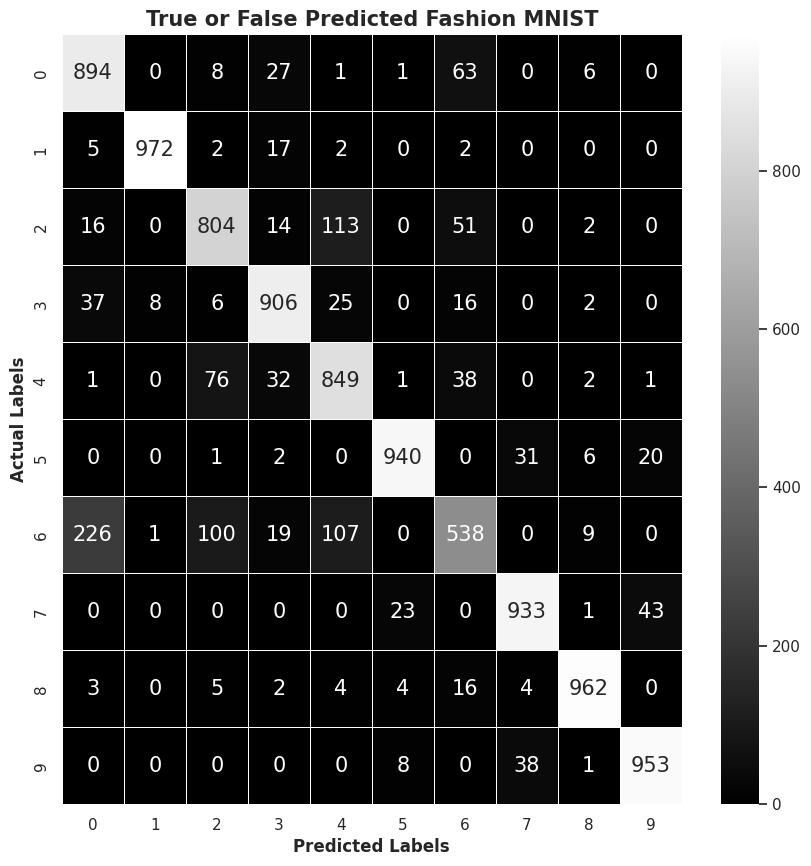

In [57]:
## Visualizing Confusion Matrix
### Displaying prediction performance using a heatmap

plt.figure(figsize=(10,10))

sns.heatmap(
    con_mat,
    annot=True,
    annot_kws={'size':15},
    linewidths=0.5,
    fmt='d',
    cmap='gray'
)

plt.title(
    'True or False Predicted Fashion MNIST',
    fontweight='bold',
    fontsize=15
)

plt.xlabel(
    'Predicted Labels',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Actual Labels',
    fontsize=12,
    fontweight='bold'
)

plt.show()

In [58]:
## Generating Classification Report
### Evaluating precision, recall, F1-score, and support metrics

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_fash_eval,
        y_predict_fash
    )
)

              precision    recall  f1-score   support

           0       0.76      0.89      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.80      0.80      0.80      1000
           3       0.89      0.91      0.90      1000
           4       0.77      0.85      0.81      1000
           5       0.96      0.94      0.95      1000
           6       0.74      0.54      0.62      1000
           7       0.93      0.93      0.93      1000
           8       0.97      0.96      0.97      1000
           9       0.94      0.95      0.94      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.87     10000
weighted avg       0.88      0.88      0.87     10000



| Metric           | Formula                                                     | Purpose                                  |
| ---------------- | ----------------------------------------------------------- | ---------------------------------------- |
| Accuracy         | `(Correct Predictions / Total Predictions)`                 | Measures overall prediction correctness  |
| Macro Average    | `(Sum of metric values of all classes) / Number of classes` | Gives equal importance to every class    |
| Weighted Average | `(Metric × Number of samples in class) / Total samples`     | Gives importance according to class size |
=========

accuracy      = 0.88,

macro avg F1  = 0.87,

weighted avg F1 = 0.87,

Total samples = 10000

=========


| Metric           |  Calculation | Result |
| ---------------- | -----------: | -----: |
| Accuracy         | `8800/10000` | `0.88` |
| Macro Average    |    `8.75/10` | `0.88` |
| Weighted Average | `8750/10000` | `0.88` |


In [59]:
## Displaying Training History Parameters
### Viewing model training and validation metrics

print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


| Metric         | Description                |
| -------------- | -------------------------- |
| `loss`         | Training loss values       |
| `accuracy`     | Training accuracy values   |
| `val_loss`     | Validation loss values     |
| `val_accuracy` | Validation accuracy values |


In [60]:
print(history.history['accuracy'])

[0.6221333146095276, 0.7473499774932861, 0.7727833390235901, 0.7826333045959473, 0.7941166758537292, 0.799916684627533, 0.8058666586875916, 0.8098833560943604, 0.8128833174705505, 0.8113499879837036, 0.8097166419029236, 0.8126333355903625, 0.8149999976158142, 0.8167999982833862, 0.8157666921615601, 0.8205999732017517, 0.8214166760444641, 0.8221499919891357, 0.8249833583831787, 0.8232166767120361, 0.824483335018158, 0.8247666954994202, 0.8266500234603882, 0.8264666795730591, 0.8261833190917969, 0.8266000151634216, 0.8262666463851929, 0.8295833468437195, 0.8303333520889282, 0.8313000202178955]


In [61]:
print(history.history['val_accuracy'])

[0.7724000215530396, 0.8399999737739563, 0.8457000255584717, 0.8529999852180481, 0.8533999919891357, 0.8550000190734863, 0.8571000099182129, 0.8535000085830688, 0.8640000224113464, 0.8628000020980835, 0.866599977016449, 0.8578000068664551, 0.8593000173568726, 0.8680999875068665, 0.8684999942779541, 0.869700014591217, 0.8705000281333923, 0.8671000003814697, 0.8654999732971191, 0.8697999715805054, 0.8564000129699707, 0.8697999715805054, 0.8693000078201294, 0.8715000152587891, 0.8676999807357788, 0.871399998664856, 0.8644000291824341, 0.8737999796867371, 0.8695999979972839, 0.8751000165939331]


In [62]:
print(history.history['val_loss'])

[0.6147878766059875, 0.49145805835723877, 0.43901190161705017, 0.4648228883743286, 0.4638667404651642, 0.45071640610694885, 0.4188847243785858, 0.4058557152748108, 0.3982701301574707, 0.4046400189399719, 0.3950113356113434, 0.39987149834632874, 0.4058528542518616, 0.38985663652420044, 0.37650594115257263, 0.37417474389076233, 0.38641664385795593, 0.38914954662323, 0.38699719309806824, 0.3890098035335541, 0.3993728756904602, 0.3776356875896454, 0.3749074637889862, 0.3912804126739502, 0.38714632391929626, 0.39957234263420105, 0.39404627680778503, 0.3675467073917389, 0.3675691783428192, 0.37468069791793823]


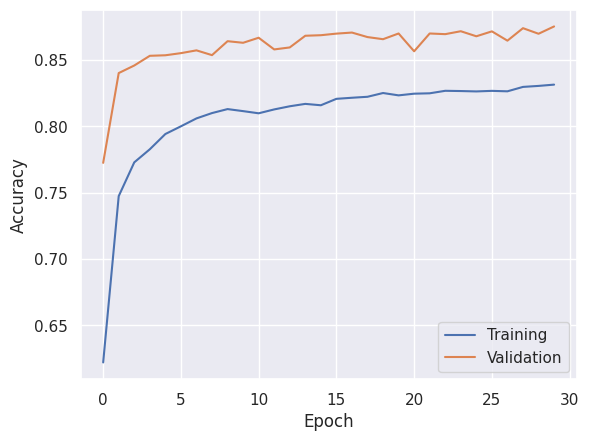

In [63]:
#These values are usually used to draw accuracy graphs:

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training','Validation'])

plt.show()

This helps you understand:

Is accuracy improving?
Is loss decreasing?
Is the model overfitting?
How training and validation compare?

=====

| Step          | Command                         | Output                                          |
| ------------- | ------------------------------- | ----------------------------------------------- |
| Train model   | `history = model.fit(...)`      | Model learns patterns from data                 |
| Store results | `history`                       | Saves training information                      |
| Check metrics | `print(history.history.keys())` | `['accuracy','loss','val_accuracy','val_loss']` |
| Use metrics   | `history.history['accuracy']`   | Get values for graphs and analysis              |

=========

| Step | Process                             | Purpose                                                     |
| ---- | ----------------------------------- | ----------------------------------------------------------- |
| 1    | Train Model                         | Train the ANN model using training data (`model.fit()`)     |
| 2    | Store Training Results              | Automatically save training details in the `history` object |
| 3    | Check Available Metrics             | Display available metrics using `history.history.keys()`    |
| 4    | Use Metrics for Graphs and Analysis | Plot accuracy/loss graphs and analyze model performance     |


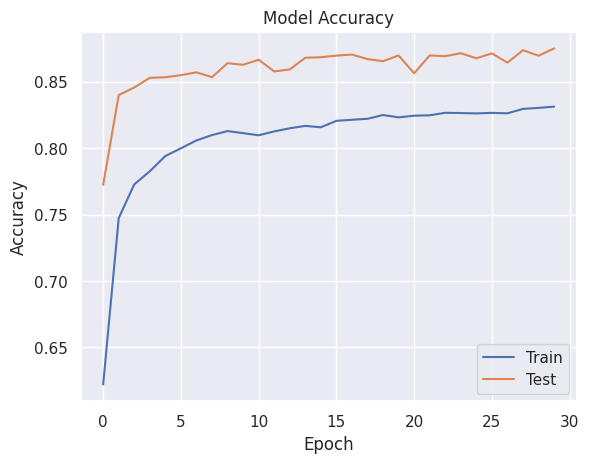

In [64]:
## Visualizing Model Accuracy
### Plotting training and validation accuracy across epochs

# Summarize history for accuracy

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(
    ['Train','Test'],
    loc='best'
)

plt.show()

| Step | Command                                     | Purpose                  |
| ---- | ------------------------------------------- | ------------------------ |
| 1    | `plt.plot(history.history['accuracy'])`     | Plot training accuracy   |
| 2    | `plt.plot(history.history['val_accuracy'])` | Plot validation accuracy |
| 3    | `plt.title('Model Accuracy')`               | Add graph title          |
| 4    | `plt.ylabel('Accuracy')`                    | Add Y-axis label         |
| 5    | `plt.xlabel('Epoch')`                       | Add X-axis label         |
| 6    | `plt.legend(['Train','Test'])`              | Add graph legend         |
| 7    | `plt.show()`                                | Display graph            |


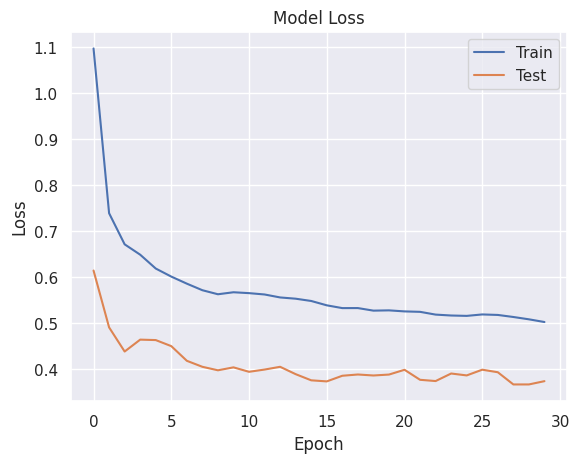

In [65]:
## Visualizing Model Loss
### Plotting training and validation loss across epochs

# Summarize history for loss

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')

plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(
    ['Train','Test'],
    loc='best'
)

plt.show()

| Step | Command                                 | Purpose                                  |
| ---- | --------------------------------------- | ---------------------------------------- |
| 1    | `plt.plot(history.history['loss'])`     | Plot training loss values                |
| 2    | `plt.plot(history.history['val_loss'])` | Plot validation loss values              |
| 3    | `plt.title('Model Loss')`               | Add graph title                          |
| 4    | `plt.ylabel('Loss')`                    | Add Y-axis label                         |
| 5    | `plt.xlabel('Epoch')`                   | Add X-axis label                         |
| 6    | `plt.legend(['Train','Test'])`          | Add legend for train and validation data |
| 7    | `plt.show()`                            | Display the graph                        |


***Epoch means one complete cycle where the entire training dataset passes through the neural network once.***

For my Fashion-MNIST project:

Training images = 60,000
epochs = 30

This means:

Epoch 1 → Model sees all 60,000 images once,

Epoch 2 → Model sees all 60,000 images again,

Epoch 3 → Model sees all 60,000 images again,
...
Epoch 30 → Model sees all 60,000 images for the 30th time

In [66]:
history = model.fit(
    X_train_fashion,
    y_train_fashion,
    batch_size=100,
    epochs=30
)

Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8290 - loss: 0.5076
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8318 - loss: 0.5013
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8296 - loss: 0.5051
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8317 - loss: 0.5058
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8329 - loss: 0.4997
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8331 - loss: 0.4982
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8347 - loss: 0.4914
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8327 - loss: 0.5006
Epoch 9/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8317 - loss: 0.5021
Epoch 10/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8342 - loss: 0.4959
Epoch 11/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8339 - loss: 0.4961
Epoch 12/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/st

| Parameter        | Value | Meaning                               |
| ---------------- | ----: | ------------------------------------- |
| Training samples | 60000 | Total images                          |
| Batch size       |   100 | Images processed at one time          |
| Epochs           |    30 | Total complete passes through dataset |


========

Steps per Epoch=

Training Samples / Batch Size

| Epoch    | Steps |
| -------- | ----: |
| Epoch 1  |   600 |
| Epoch 2  |   600 |
| Epoch 3  |   600 |
| ...      |   ... |
| Epoch 30 |   600 |

===========

| Step | Process                     |
| ---- | --------------------------- |
| 1    | Load all training images    |
| 2    | Divide images into batches  |
| 3    | Train on all batches        |
| 4    | Complete one epoch          |
| 5    | Repeat for remaining epochs |

===========

Purpose of multiple epochs:

Improve model learning,

Reduce prediction error,

Increase accuracy
============

Too few epochs → underfitting,

Too many epochs → overfitting
=============

Steps per Epoch=


Training Samples / Batch Size,


60000 / 100 = 600 steps

=======



| Epoch | Accuracy (Example) |
| ----- | -----------------: |
| 1     |                72% |
| 5     |                81% |
| 10    |                85% |
| 20    |                87% |
| 30    |                88% |
| 50    |              88.2% |
| 100   |              88.1% |


In [67]:
## Predicting a Single Fashion Image
### Generating prediction for a selected test image

# Expand dimensions for single image prediction

y_predict = model.predict(
    X_test_fashion.loc[[0],:].values
)

y_predict = np.argmax(
    y_predict,
    axis=1
)

y_test_digit_eval = np.argmax(
    y_test_fashion,
    axis=1
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [68]:
## Defining Clothing Categories
### Creating labels for Fashion-MNIST classes

# Names of clothing accessories in order

col_names = [
'T-shirt/top',
'Trouser',
'Pullover',
'Dress',
'Coat',
'Sandal',
'Shirt',
'Sneaker',
'Bag',
'Ankle boot'
]

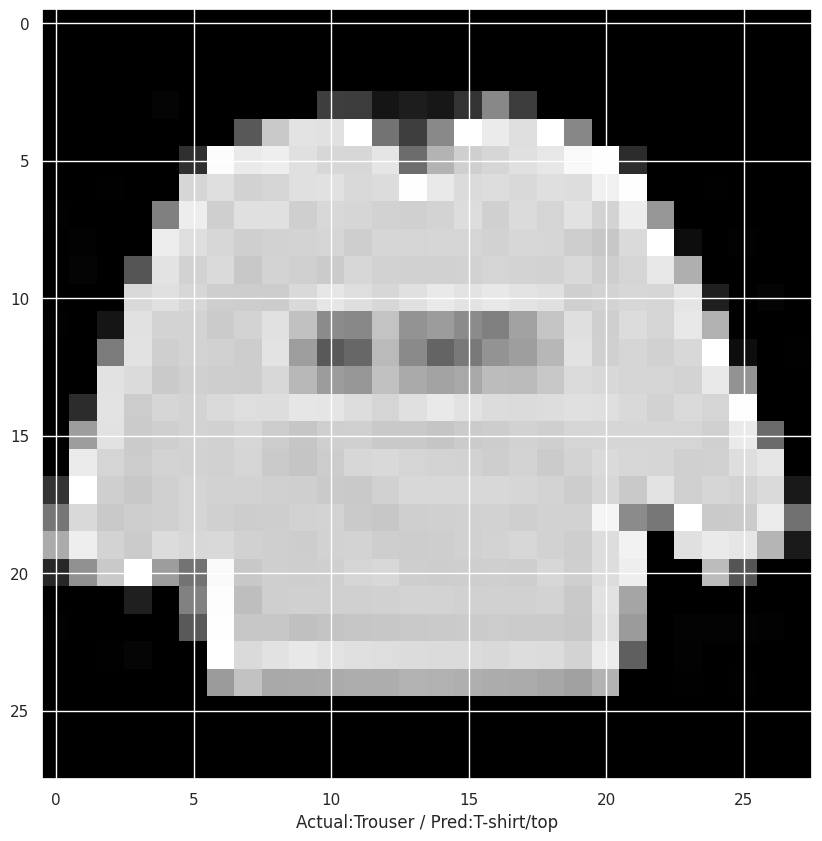

In [72]:
## Visualizing Predicted Image Result
### Displaying actual and predicted clothing labels

# Visualizing the image

plt.figure(figsize=(10,10))

plt.imshow(
    X_train_reshape[0],
    cmap='gray'
)

plt.xlabel(
    "Actual:{} / Pred:{}".format(
        col_names[np.argmax(y_test_fashion[1])],
        col_names[y_predict[0]]
    )
)

plt.show()

"The model incorrectly classified the image. The actual category is Trouser, but the predicted category is T-shirt/top. This indicates a prediction mismatch for this sample. Such errors can occur because the model learns from pixel patterns and some samples may contain patterns that are interpreted differently by the ANN model."

=============

| Parameter          | Result                                     |
| ------------------ | ------------------------------------------ |
| Actual Category    | Trouser                                    |
| Predicted Category | T-shirt/top                                |
| Prediction Status  | Incorrect Prediction                       |
| Observation        | Model prediction differs from actual label |


| Parameter            | Observation                               |
| -------------------- | ----------------------------------------- |
| Image type           | Grayscale image                           |
| Resolution           | 28 × 28 pixels                            |
| Image quality        | Low resolution, enlarged and blurred      |
| Visible pattern      | Upper clothing shape is visible           |
| Model interpretation | Appears similar to a shirt/top category   |
| Reason for blur      | Small pixel image enlarged during display |


| Step | Command           | Purpose                               |
| ---- | ----------------- | ------------------------------------- |
| 1    | `model.predict()` | Predict selected image                |
| 2    | `np.argmax()`     | Convert probabilities to class index  |
| 3    | `col_names[]`     | Convert class number to clothing name |
| 4    | `plt.imshow()`    | Display image                         |
| 5    | `plt.xlabel()`    | Show actual and predicted labels      |
| 6    | `plt.show()`      | Display result                        |


=============

| Category             | Why confusion occurs                 |
| -------------------- | ------------------------------------ |
| T-shirt/top ↔ Shirt  | Similar upper-body shape and sleeves |
| Pullover ↔ Coat      | Similar body structure               |
| Shirt ↔ Coat         | Similar outline after resizing       |
| Sneaker ↔ Ankle boot | Similar shoe patterns                |

=============

"The image appears similar to an upper-wear category, and the model may confuse Shirt with T-shirt/top because of similar visual patterns."

"The image looks blurred because of the 28x28 resolution, but the ANN model uses pixel values and learned features to classify the clothing category accurately."

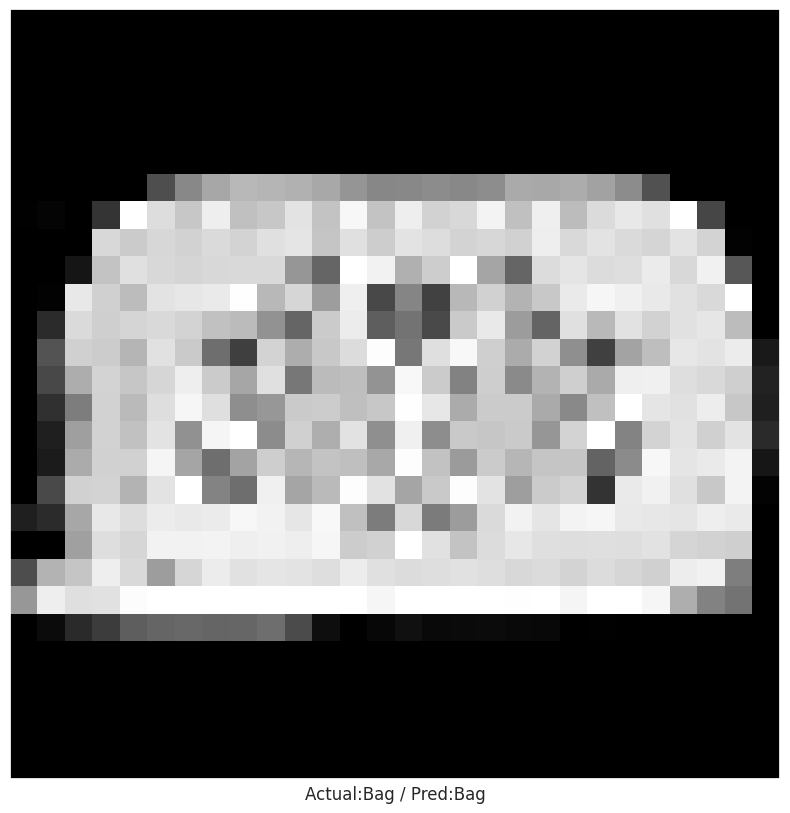

In [93]:
# Find the image

image_index = np.where(
    np.argmax(y_test_fashion, axis=1) == 8
)[0][0]

plt.figure(figsize=(10,10))

plt.imshow(
    X_test_reshape[image_index],
    cmap='gray'
)

plt.xlabel(
    "Actual:{} / Pred:{}".format(
        col_names[np.argmax(y_test_fashion[image_index])],
        col_names[y_predict_fash[image_index]]
    )
)

plt.xticks([])
plt.yticks([])

plt.show()

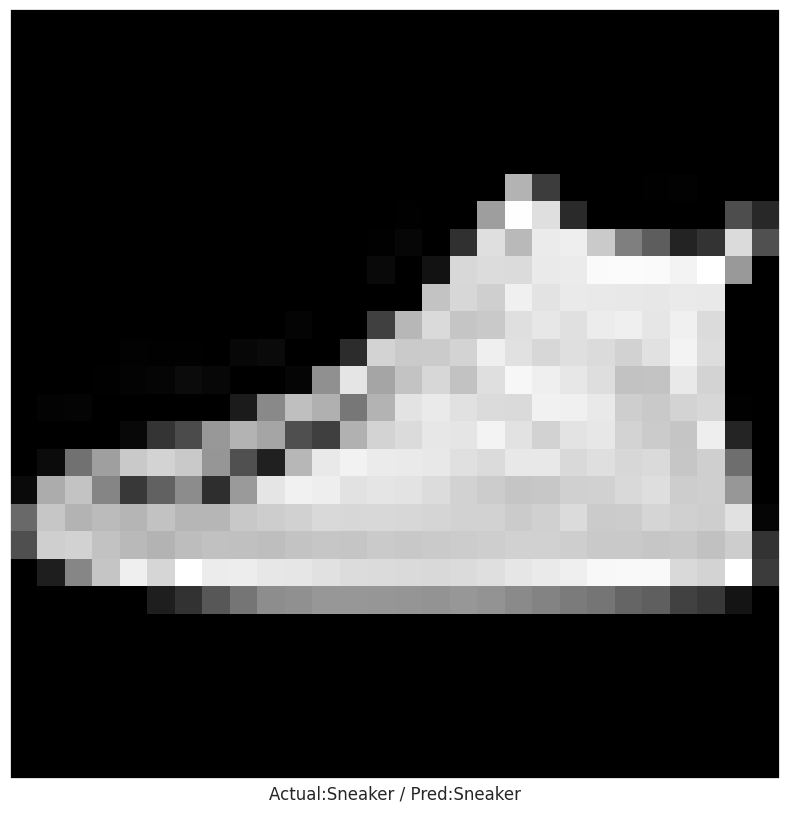

In [94]:

image_index = np.where(
    np.argmax(y_test_fashion, axis=1) == 7
)[0][0]

plt.figure(figsize=(10,10))

plt.imshow(
    X_test_reshape[image_index],
    cmap='gray'
)

plt.xlabel(
    "Actual:{} / Pred:{}".format(
        col_names[np.argmax(y_test_fashion[image_index])],
        col_names[y_predict_fash[image_index]]
    )
)

plt.xticks([])
plt.yticks([])

plt.show()

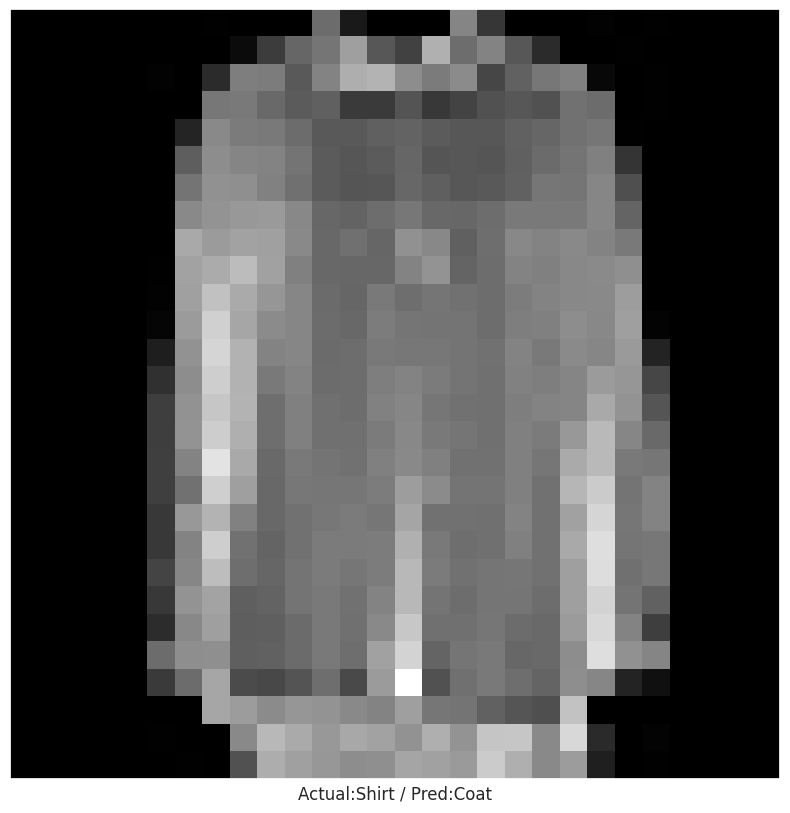

In [95]:

image_index = np.where(
    np.argmax(y_test_fashion, axis=1) == 6
)[0][0]

plt.figure(figsize=(10,10))

plt.imshow(
    X_test_reshape[image_index],
    cmap='gray'
)

plt.xlabel(
    "Actual:{} / Pred:{}".format(
        col_names[np.argmax(y_test_fashion[image_index])],
        col_names[y_predict_fash[image_index]]
    )
)

plt.xticks([])
plt.yticks([])

plt.show()

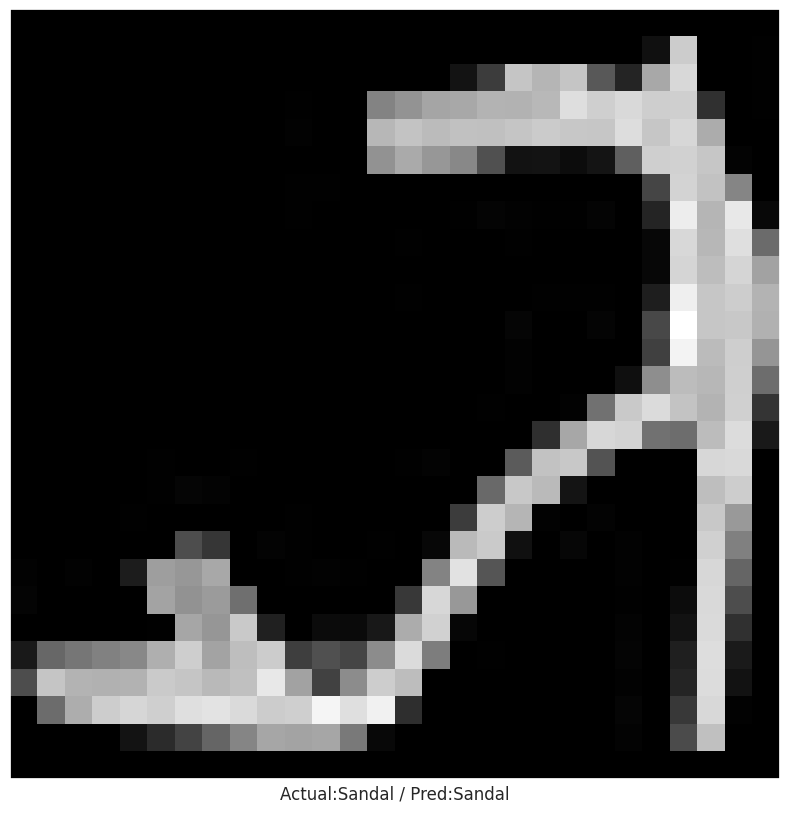

In [99]:
# Select image index
i = 8

plt.figure(figsize=(10,10))

plt.imshow(
    X_test_reshape[i],
    cmap='gray'
)

plt.xlabel(
    "Actual:{} / Pred:{}".format(
        col_names[np.argmax(y_test_fashion[i])],
        col_names[y_predict_fash[i]]
    )
)

plt.xticks([])
plt.yticks([])

plt.show()

| Parameter          | Result                            |
| ------------------ | --------------------------------- |
| Actual Category    | Sandal                            |
| Predicted Category | Sandal                            |
| Prediction Status  | Correct Prediction                |
| Observation        | Actual and predicted labels match |


==============

##Project/report conclusion:

"**The model successfully classified** the given Fashion-MNIST image. The actual category and predicted category are both Sandal, indicating that the **ANN model correctly learned and identified the image features based on pixel patterns."**

| Step | Process                          | Description                                                                      |
| ---- | -------------------------------- | -------------------------------------------------------------------------------- |
| 1    | New products arrive at warehouse | Different products such as shirts, shoes, bags, and trousers enter the warehouse |
| 2    | Camera captures product image    | A camera takes an image of the product                                           |
| 3    | Send image to ANN model          | The captured image is given as input to the ANN model                            |
| 4    | Analyze pixel patterns           | The ANN processes image pixel values and learns features                         |
| 5    | Identify product category        | The model predicts the product type                                              |
| 6    | Category example                 | Shoe → Footwear Section, Bag → Accessories Section, Shirt → Clothing Section     |
| 7    | Automatically organize products  | Products are placed into the correct storage section                             |
| 8    | Final result                     | Less manual work, faster operation, and fewer errors                             |


| Flow                            |
| ------------------------------- |
| Products arrive                 |
| ↓                               |
| Capture image                   |
| ↓                               |
| Send to ANN model               |
| ↓                               |
| Analyze pixel patterns          |
| ↓                               |
| Identify category               |
| ↓                               |
| Organize products automatically |
| ↓                               |
| Faster operation + fewer errors |


##This project acts like an intelligent assistant for warehouses and stores. Instead of manually checking products, the ANN model automatically recognizes and organizes items into the correct category, improving efficiency and reducing human effort."